In [1]:
import cv2
from ultralytics import YOLO
import os
import time
import numpy as np
import faiss
import sys

In [2]:
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
import clip_encoder

In [4]:
# Load YOLO
model = YOLO("yolov8n.pt")

# Load prebuilt FAISS index + paths
index = faiss.read_index("data/index.faiss")
with open("data/paths.txt", "r") as f:
    gallery_paths = f.read().splitlines()

# Output directory for live crops (optional, just to visualize/save)
output_dir = "data/cropped_objects"
os.makedirs(output_dir, exist_ok=True)

# Set similarity threshold
SIM_THRESHOLD = 0.6  # tune this as per your embedding scale

In [13]:
cap = cv2.VideoCapture(0)
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)[0]

    for i, box in enumerate(results.boxes.xyxy):
        x1, y1, x2, y2 = map(int, box[:4])
        cropped = frame[y1:y2, x1:x2]

        # Save crop (optional, for debugging)
        timestamp = int(time.time() * 1000)
        filename = f"{output_dir}/crop_{frame_count}_{i}_{timestamp}.jpg"
        cv2.imwrite(filename, cropped)

        # Embed crop
        emb = clip_encoder.embed_image(filename).astype("float32")
        faiss.normalize_L2(emb)

        # Search in gallery index
        D, I = index.search(emb, k=1)  # top-1 match
        best_score = D[0][0]
        best_match_idx = I[0][0]

        if best_score >= SIM_THRESHOLD:
            matched_path = gallery_paths[best_match_idx]
            text = f"FOUND: {os.path.basename(matched_path)} ({best_score:.2f})"
            color = (0, 0, 255)  # Red alert
        else:
            text = f"No match ({best_score:.2f})"
            color = (0, 255, 0)  # Green normal

        # Draw box + label
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, text, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.imshow("Live-Feed", frame)
    frame_count += 1

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 184.4ms
Speed: 72.0ms preprocess, 184.4ms inference, 53.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 80.1ms
Speed: 7.8ms preprocess, 80.1ms inference, 7.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 68.2ms
Speed: 7.0ms preprocess, 68.2ms inference, 6.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 71.2ms
Speed: 5.8ms preprocess, 71.2ms inference, 3.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 64.7ms
Speed: 5.2ms preprocess, 64.7ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 61.0ms
Speed: 7.4ms preprocess, 61.0ms inference, 6.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 69.6ms
Speed: 8.3ms preprocess, 69.6ms inference, 11.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 54.5ms
Speed: 3.7ms preprocess, 54.5ms inference, 5.0ms postprocess per image at shape (1, 

In [12]:
cap.release()
cv2.destroyAllWindows()

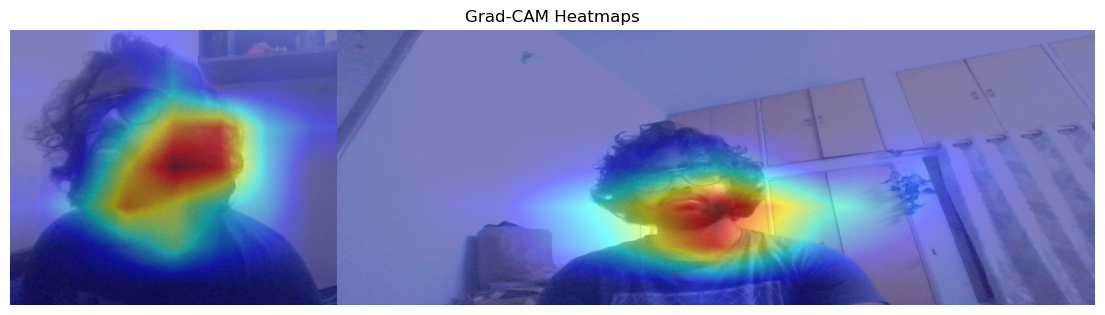

In [2]:
from explain import explain

# Paths to your query image and the matched image returned by FAISS
query_path = "data/cropped_objects/crop_0_0_1759071361382.jpg"
matched_path = "data/test_data/person.jpg"

result = explain(query_path, matched_path)